# **Create Smoke Set**

## *Smoke Set Imports*

In [1]:

from earthscape.constants import *
from earthscape.utils import *
from earthscape.splits.trainvaltestsplits_utils import *

import os
import glob
import shutil
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio

## *Select Train-Val-Test Splits*

In [ ]:
##################################################
# Select Smoke Splits from Train/Val/Test Splits
##################################################

# set parameters...

if not os.path.isdir(SMOKE_DIR):
    os.makedirs(SMOKE_DIR)

if not os.path.isdir(SMOKE_SPLITS_DIR):
    os.makedirs(SMOKE_SPLITS_DIR)

seed = 111
set_seed(111)



##### select and save smoke splits
train = make_smoke_set(f"{DATASET_DIR}/{GLOBAL_AREAS_BASE}", f"../models/{SPLIT_DIR}/{STR_VERSION}_train.geojson", split_size=7, threshold=0)
train.drop(columns=train.columns[2:], inplace=True)
train.to_file(f"{SMOKE_SPLITS_DIR}/smoke_{STR_VERSION}_train.geojson", driver='GeoJSON', index=False)

val = make_smoke_set(f"{DATASET_DIR}/{GLOBAL_AREAS_BASE}", f"../models/{SPLIT_DIR}/{STR_VERSION}_val.geojson", split_size=7, threshold=0)
val.drop(columns=val.columns[2:], inplace=True)
val.to_file(f"{SMOKE_SPLITS_DIR}/smoke_{STR_VERSION}_val.geojson", driver='GeoJSON', index=False)

test = make_smoke_set(f"{DATASET_DIR}/{GLOBAL_AREAS_BASE}", f"../models/{SPLIT_DIR}/{STR_VERSION}_test.geojson", split_size=7, threshold=0)
test.drop(columns=test.columns[2:], inplace=True)
test.to_file(f"{SMOKE_SPLITS_DIR}/smoke_{STR_VERSION}_test.geojson", driver='GeoJSON', index=False)

cross_test = make_smoke_set(f"{DATASET_DIR}/{GLOBAL_AREAS_BASE}", f"../models/{SPLIT_DIR}/{STR_VERSION}_cross.geojson", split_size=7, threshold=0)
cross_test.drop(columns=cross_test.columns[2:], inplace=True)
cross_test.to_file(f"{SMOKE_SPLITS_DIR}/smoke_{STR_VERSION}_cross.geojson", driver='GeoJSON', index=False)


## *Save Smoke Patches*

In [4]:
##################################################
# Copy and save smoke set images to data folder.
##################################################

# paths to patches directories
# dataset_dir = r'../data'
area_dirs = [d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))]

# output directory
if not os.path.isdir(SMOKE_PATCHES_DIR):
    os.makedirs(SMOKE_PATCHES_DIR)

# list of all smoke patch IDs
all_patch_ids = train['patch_id'].astype(str).to_list()\
                + val['patch_id'].to_list()\
                + test['patch_id'].astype(str).to_list()\
                + cross_test['patch_id'].astype(str).to_list()


##### get paths to patches...
paths = []
for pid in all_patch_ids:
    for ad in area_dirs:
        candidate_dir = glob.glob(f"{DATASET_DIR}/{ad}/patches_*")[0]
        if os.path.isdir(candidate_dir):
            match_img = glob.glob(f"{candidate_dir}/{pid}_*.tif")
            match_csv = glob.glob(f"{candidate_dir}/{pid}_*.csv")
            if len(match_img) > 0:
                paths.extend(match_img)
                paths.extend(match_csv)
            

##### save data to smoke dataset directory...
for src in paths:
    basename = os.path.basename(src)
    dst = f"{SMOKE_PATCHES_DIR}/{basename}"
    shutil.copy2(src, dst)
    

## *Save Global Smoke Files*

In [ ]:
#####################################################################################
# Save global files to mimic same structure as other local area dataset directories.
#####################################################################################


##### get smoke set patch IDs...
smoke_ids = train['patch_id'].astype(str).to_list()\
            + val['patch_id'].to_list()\
            + test['patch_id'].astype(str).to_list()\
            + cross_test['patch_id'].astype(str).to_list()


##### extract areas, patches, and stats files for smoke set...
area = pd.read_csv(f"{DATASET_DIR}/{GLOBAL_AREAS_BASE}")
area = area.loc[area['patch_id'].isin(smoke_ids)]
area.to_csv(f"{SMOKE_DIR}/smoke_{STR_VERSION}_areas.csv", index=False)

patches = gpd.read_file(f"{DATASET_DIR}/{GLOBAL_PATCHES_BASE}")
patches = patches.loc[patches['patch_id'].isin(smoke_ids)]
patches.to_file(f"{SMOKE_DIR}/smoke_{STR_VERSION}_patches.geojson", driver='GeoJSON', index=False)

src = f"{SPLIT_DIR}/{STR_VERSION}_train_stats.csv"
dst = f"{SMOKE_DIR}/smoke_{STR_VERSION}_stats.csv"
shutil.copy2(src, dst)

'../smoke/smoke_v1-1_stats.csv'

# **Smoke Set Training & Testing**

## *Modeling Imports*

In [3]:

from earthscape.utils import *
from earthscape.constants import *
from earthscape.models.earthscape_dataset import *
from earthscape.models.sgmapnet import *
from earthscape.models.focal_loss import *
from earthscape.models.training_utils import *

import os
import datetime
import pandas as pd
import geopandas as gpd
import torch
from torch.utils.data import DataLoader
import torch.optim as optim
# from torchinfo import summary
import matplotlib.pyplot as plt


## *Model Parameters*

In [4]:
############################################################
# Define parameters for training, validation, and testing
############################################################

# set seed for reproducibility
seed = 111
set_seed(seed)

# dict of informal name (modality) & list of file suffixes (channels)
modality_configs = {
    'dem': {
        'channels': ['dem.tif']
        }, 
    # 'aerial': {
    #     'channels': ['aerialr.tif', 'aerialg.tif', 'aerialb.tif']
    #     }
    }

# get normalization parameters for input modalities/channels
modality_configs = get_norm_stats(f"{DATASET_DIR}/{GLOBAL_STATS_BASE}", modality_configs)


# list of directories containing patch data
patch_dirs = [r'../data/warren/patches_warren', 
              r'../data/howevalley/patches_howevalley', 
              r'../data/sonora/patches_sonora']


# get patch IDs & create pytorch datasets...
# training set
gdf = gpd.read_file(f"{SMOKE_SPLITS_DIR}/smoke_{STR_VERSION}_train.geojson")
train_patch_ids = gdf['patch_id'].to_list()
train_dataset = EarthScape_Dataset(train_patch_ids, patch_dirs, modality_configs, augment=True)

# validation set
gdf = gpd.read_file(f"{SMOKE_SPLITS_DIR}/smoke_{STR_VERSION}_val.geojson")
val_patch_ids = gdf['patch_id'].to_list()
val_dataset = EarthScape_Dataset(val_patch_ids, patch_dirs, modality_configs, augment=False)

# test set
gdf = gpd.read_file(f"{SMOKE_SPLITS_DIR}/smoke_{STR_VERSION}_test.geojson")
test_patch_ids = gdf['patch_id'].to_list()
test_dataset = EarthScape_Dataset(test_patch_ids, patch_dirs, modality_configs, augment=False)

# cross-domain test set
gdf = gpd.read_file(f"{SMOKE_SPLITS_DIR}/smoke_{STR_VERSION}_cross.geojson")
cross_test_patch_ids = gdf['patch_id'].to_list()
cross_test_dataset = EarthScape_Dataset(cross_test_patch_ids, patch_dirs, modality_configs, augment=False)


# model hyperparameters & settings...
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 2
num_epochs = 5
encoder = 'vit'
model = SGMapNet_Classification(modality_configs, encoder, enable_attention=False, embedding_dim=512, num_heads=8, p_attn=0.0, p_resid=0.0).to(device)
optimizer = optim.Adam(model.parameters())


# dataloaders...
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
cross_test_loader = DataLoader(cross_test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)


# focal loss...
reduction = 'mean'
gamma = 2.0
alpha = 0.25
alpha = torch.tensor(alpha, dtype=torch.float32).view(1, -1).to(device)
criterion = FocalLoss(alpha=alpha, gamma=gamma, reduction=reduction).to(device)


# create output directory...
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
modality_str = '_'.join(list(modality_configs.keys()))
model_name = f"{encoder}_{modality_str}_{timestamp}"
output_dir = f"{MODEL_CLF_DIR}/{model_name}"
if not os.path.isdir(output_dir):
    os.makedirs(output_dir)
else:
    print('Directory already exists...')


# log metadata
training_log(model_name, output_dir, seed,
             train_patch_ids, val_patch_ids, test_patch_ids, cross_test_patch_ids,
             modality_configs, 
             batch_size, num_epochs, optimizer, criterion, model)

## *DataLoader Example*

In [6]:
# extract example
example = next(iter(val_loader))

# print data report
for modality in example.keys():
    print(modality)
    print(f"{type(example[modality])}  |  {example[modality].dtype}  |  {example[modality].shape}  |  {example[modality].min()}  |  {example[modality].max()}")

label
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([2, 7])  |  0.0  |  1.0
dem
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([2, 1, 256, 256])  |  -2.1420960426330566  |  1.7606350183486938


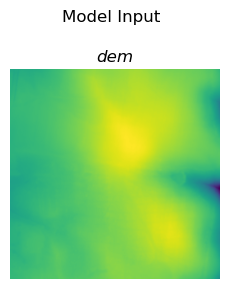

In [7]:
# extract total number of channels to plot...
num_channels = 0
for k,v in example.items():
    if not 'label' in k:
        num_channels += v.shape[1]

# define number of columns & rows...
ncols = min(4, num_channels)
nrows = (num_channels // ncols) + 1

# setup figure...
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 3*nrows))
ax = ax.ravel()

# plot channels separately...
idx = 0
for k,v in example.items():
    if 'label' in k:
        label = v.detach().numpy()[0]
        fig.suptitle(f"Model Input")
    else:
        v_sample = v.detach().numpy()[0]
        for c in range(v_sample.shape[0]):
            img = v_sample[c]
            min_val = img.min()
            max_val = img.max()
            img = (img - min_val) / (max_val - min_val + 1e-8)
            ax[idx].imshow(img)
            ax[idx].set_axis_off()
            ax[idx].set_title(k, style='italic')
            idx += 1

# remove any extra subplot axes...
for j in range(idx, len(ax)):
    fig.delaxes(ax[j])

plt.show()

## *Training*

In [8]:
df_train = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs, output_dir)

Epoch 1
TRAINING   -- Loss: 0.0511  |  Accuracy: 57.14%  |  Time: 0.02 mins.
VALIDATION -- Loss: 0.0355  |  Accuracy: 69.05%  |  Time: 0.0 mins.
New best model saved!


Epoch 2
TRAINING   -- Loss: 0.0359  |  Accuracy: 66.67%  |  Time: 0.02 mins.
VALIDATION -- Loss: 0.0439  |  Accuracy: 71.43%  |  Time: 0.0 mins.


Epoch 3
TRAINING   -- Loss: 0.0433  |  Accuracy: 76.19%  |  Time: 0.02 mins.
VALIDATION -- Loss: 0.0395  |  Accuracy: 69.05%  |  Time: 0.0 mins.


Epoch 4
TRAINING   -- Loss: 0.0339  |  Accuracy: 71.43%  |  Time: 0.02 mins.
VALIDATION -- Loss: 0.0382  |  Accuracy: 71.43%  |  Time: 0.0 mins.


Epoch 5
TRAINING   -- Loss: 0.0288  |  Accuracy: 80.95%  |  Time: 0.02 mins.
VALIDATION -- Loss: 0.0389  |  Accuracy: 71.43%  |  Time: 0.0 mins.




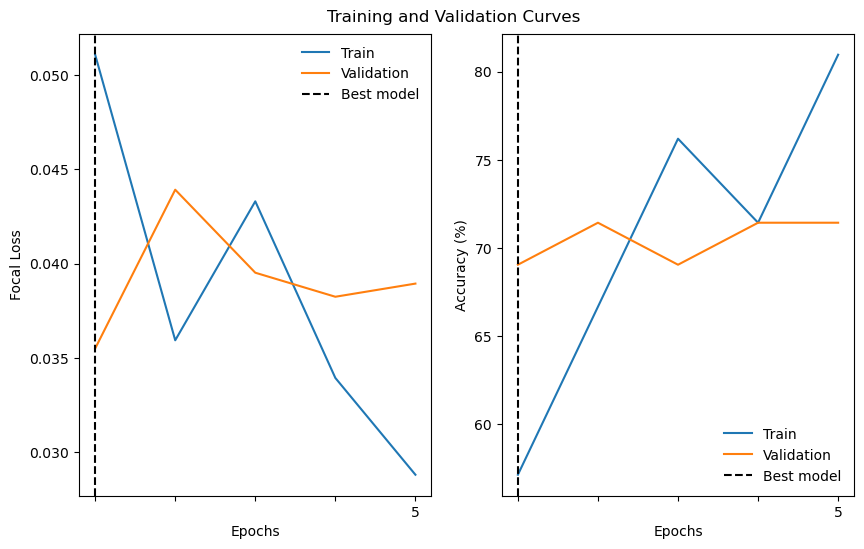

In [9]:
fig = plot_training_curves(df_train, output_dir)

fig.savefig(f"{output_dir}/training_curves.png", dpi=300, bbox_inches='tight', pad_inches=0)

## *Threshold Tuning*

In [10]:
model_path = glob.glob(f"{output_dir}/best_loss_epoch*.pth")[0]

state_dict = torch.load(model_path, map_location=device, weights_only=False)

model.load_state_dict(state_dict)

optimal_thresholds = calculate_optimal_thresholds(model, val_loader, device)

## *In-domain Inference*

In [11]:
probabilities, targets = test_model(model, test_loader, device)

df_global = calculate_global_metrics(targets, probabilities, thresholds=optimal_thresholds)

df_global.to_csv(f"{output_dir}/indomain_model_performance.csv", index=False)

df_global.head()

/opt/miniconda3/envs/earthscape/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/miniconda3/envs/earthscape/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,Precision,Recall,F1,AUC,mAP,Precision (Wt.),Recall (Wt.),F1 (Wt.),AUC (Wt.),mAP (Wt.),Accuracy (Micro)
0,0.452381,0.714286,0.523067,NaN,0.544286,0.690476,0.904762,0.763389,NaN,0.737302,0.547619


In [12]:
df_class = calculate_class_metrics(targets, probabilities, thresholds=optimal_thresholds)

df_class.to_csv(f"{output_dir}/indomain_class_performance.csv", index=False)

df_class.head(10)

/opt/miniconda3/envs/earthscape/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,Class,True,Predicted,Accuracy,Precision,Recall,F1,AUC,AP
0,af1 (0.53),3.0,6.0,0.500000,0.500000,1.0,0.666667,0.777778,0.866667
1,Qal (0.72),5.0,6.0,0.833333,0.833333,1.0,0.909091,0.200000,0.810000
2,Qaf (0.23),1.0,3.0,0.333333,0.000000,0.0,0.000000,0.200000,0.200000
3,Qat (0.5),1.0,3.0,0.333333,0.000000,0.0,0.000000,0.200000,0.200000
4,Qc (0.65),4.0,6.0,0.666667,0.666667,1.0,0.800000,0.125000,0.566667
5,Qca (0.39),1.0,6.0,0.166667,0.166667,1.0,0.285714,0.000000,0.166667
6,Qr (0.48),6.0,6.0,1.000000,1.000000,1.0,1.000000,NaN,1.000000


/opt/miniconda3/envs/earthscape/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1192: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


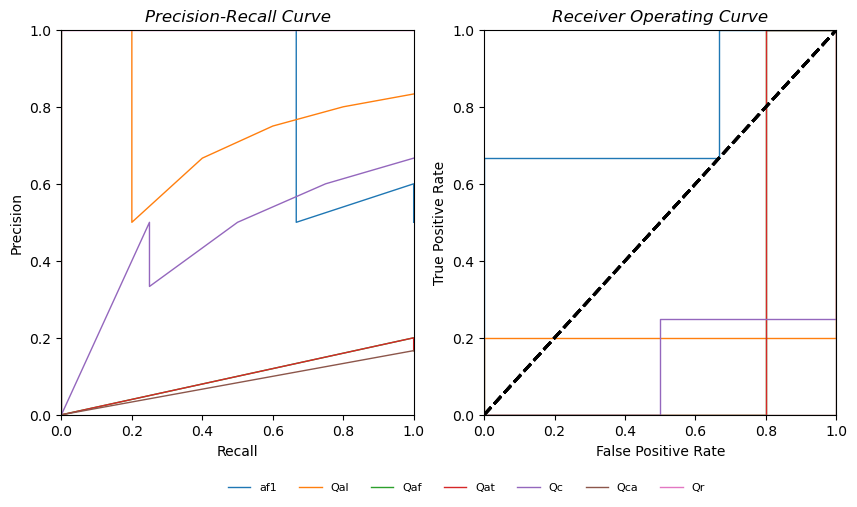

In [13]:
fig = plot_label_pr_roc_curves(targets, probabilities)

fig.savefig(f"{output_dir}/indomain_pr_curves.jpg")

## *Cross-domain Inference*

In [14]:
probabilities, targets = test_model(model, cross_test_loader, device)

df_cross_global = calculate_global_metrics(targets, probabilities, thresholds=optimal_thresholds)

df_cross_global.to_csv(f"{output_dir}/crossdomain_model_performance.csv", index=False)

df_cross_global.head()

/opt/miniconda3/envs/earthscape/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/miniconda3/envs/earthscape/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,Precision,Recall,F1,AUC,mAP,Precision (Wt.),Recall (Wt.),F1 (Wt.),AUC (Wt.),mAP (Wt.),Accuracy (Micro)
0,0.433333,0.757143,0.499258,NaN,0.702619,0.635,0.8,0.662013,NaN,0.775833,0.5


In [15]:
df_cross_class = calculate_class_metrics(targets, probabilities, thresholds=optimal_thresholds)

df_cross_class.to_csv(f"{output_dir}/crossdomain_class_performance.csv", index=False)

df_cross_class.head(10)

/opt/miniconda3/envs/earthscape/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/earthscape/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,Class,True,Predicted,Accuracy,Precision,Recall,F1,AUC,AP
0,af1 (0.53),2.0,6.0,0.333333,0.333333,1.000000,0.500000,0.25,0.325000
1,Qal (0.72),5.0,5.0,0.666667,0.800000,0.800000,0.800000,0.40,0.876667
2,Qaf (0.23),1.0,6.0,0.166667,0.166667,1.000000,0.285714,1.00,1.000000
3,Qat (0.5),1.0,0.0,0.833333,0.000000,0.000000,0.000000,0.60,0.333333
4,Qc (0.65),3.0,5.0,0.333333,0.400000,0.666667,0.500000,0.00,0.383333
5,Qca (0.39),2.0,6.0,0.333333,0.333333,1.000000,0.500000,1.00,1.000000
6,Qr (0.48),6.0,5.0,0.833333,1.000000,0.833333,0.909091,NaN,1.000000


/opt/miniconda3/envs/earthscape/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1192: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


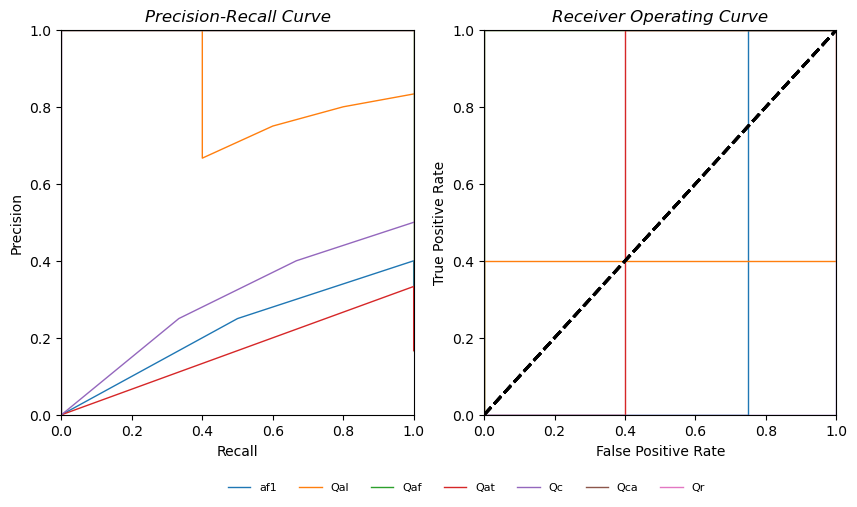

In [16]:
fig = plot_label_pr_roc_curves(targets, probabilities)

fig.savefig(f"{output_dir}/crossdomain_pr_curves.jpg")